# Baseline Models

This notebook establishes two benchmarks that later CatBoost models must beat:

1. A fold-specific constant prediction equal to the training make rate.
2. An L2-regularized logistic regression with scaling and one-hot encoding fitted inside each training fold.

Evaluation uses expanding season-held-out folds. The 2024-25 final holdout is not loaded.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.features import build_features, extract_target
from src.modeling import (
    calibration_table,
    constant_probability,
    evaluate_probabilities,
    make_logistic_pipeline,
)

pd.set_option("display.float_format", lambda value: f"{value:,.5f}")
sns.set_theme(style="whitegrid")

## 1. Expanding temporal validation

Each fold trains only on earlier seasons. This is stricter and more realistic than randomly mixing shots from the same season across training and validation.

In [2]:
season_paths = {
    "2021-22": PROJECT_ROOT / "data" / "raw" / "2021.parquet",
    "2022-23": PROJECT_ROOT / "data" / "raw" / "2022.parquet",
    "2023-24": PROJECT_ROOT / "data" / "raw" / "2023.parquet",
}
raw_by_season = {label: pd.read_parquet(path) for label, path in season_paths.items()}

folds = [
    {"fold": "2021-22 to 2022-23", "train": ["2021-22"], "validation": "2022-23"},
    {"fold": "2021-23 to 2023-24", "train": ["2021-22", "2022-23"], "validation": "2023-24"},
]

pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "training_seasons": ", ".join(fold["train"]),
            "validation_season": fold["validation"],
            "training_rows": sum(len(raw_by_season[label]) for label in fold["train"]),
            "validation_rows": len(raw_by_season[fold["validation"]]),
        }
        for fold in folds
    ]
)

,fold,training_seasons,validation_season,training_rows,validation_rows
0,2021-22 to 2022-23,2021-22,2022-23,216722,217218
1,2021-23 to 2023-24,"2021-22, 2022-23",2023-24,433940,218701


## 2. Fit both baselines inside each fold

The constant benchmark uses only the training-fold target mean. The logistic pipeline fits numeric scaling and categorical encoding only on the training fold, with unknown validation categories safely ignored.

In [3]:
result_records = []
fold_artifacts = {}

for fold in folds:
    train_raw = pd.concat([raw_by_season[label] for label in fold["train"]], ignore_index=True)
    validation_raw = raw_by_season[fold["validation"]].reset_index(drop=True)

    x_train = build_features(train_raw)
    y_train = extract_target(train_raw)
    x_validation = build_features(validation_raw)
    y_validation = extract_target(validation_raw)

    constant_predictions = constant_probability(y_train, len(y_validation))
    constant_metrics = evaluate_probabilities(y_validation, constant_predictions)

    logistic_model = make_logistic_pipeline(regularization_strength=1.0)
    logistic_model.fit(x_train, y_train)
    logistic_predictions = logistic_model.predict_proba(x_validation)[:, 1]
    logistic_metrics = evaluate_probabilities(y_validation, logistic_predictions)

    for model_name, metrics in [
        ("Constant", constant_metrics),
        ("Logistic regression", logistic_metrics),
    ]:
        result_records.append(
            {
                "fold": fold["fold"],
                "model": model_name,
                "training_rows": len(y_train),
                "validation_rows": len(y_validation),
                "training_make_rate": y_train.mean(),
                "validation_make_rate": y_validation.mean(),
                **metrics,
            }
        )

    fold_artifacts[fold["fold"]] = {
        "target": y_validation,
        "constant_predictions": constant_predictions,
        "logistic_predictions": logistic_predictions,
        "logistic_model": logistic_model,
    }

baseline_results = pd.DataFrame(result_records)
baseline_results

,fold,model,training_rows,validation_rows,training_make_rate,validation_make_rate,log_loss,brier_score,ece
0,2021-22 to 2022-23,Constant,216722,217218,0.46110,0.47537,0.69234,0.24960,0.01428
1,2021-22 to 2022-23,Logistic regression,216722,217218,0.46110,0.47537,0.63955,0.22531,0.01310
2,2021-23 to 2023-24,Constant,433940,218701,0.46824,0.47434,0.69190,0.24938,0.00610
3,2021-23 to 2023-24,Logistic regression,433940,218701,0.46824,0.47434,0.64110,0.22603,0.01137


## 3. Compare probability quality

Log loss is the primary metric because it rewards accurate probabilities and strongly penalizes confident mistakes. Brier score measures squared probability error. Ten-bin expected calibration error (ECE) summarizes the gap between predicted and observed rates; it is descriptive and depends on the chosen bins. Lower is better for all three metrics.

In [4]:
metric_table = baseline_results.pivot(index="fold", columns="model", values=["log_loss", "brier_score", "ece"])
display(metric_table)

constant_rows = baseline_results.query("model == 'Constant'").set_index("fold")
logistic_rows = baseline_results.query("model == 'Logistic regression'").set_index("fold")
improvement = pd.DataFrame(
    {
        "log_loss_reduction": constant_rows["log_loss"] - logistic_rows["log_loss"],
        "log_loss_reduction_pct": (constant_rows["log_loss"] - logistic_rows["log_loss"]) / constant_rows["log_loss"],
        "brier_reduction": constant_rows["brier_score"] - logistic_rows["brier_score"],
    }
)
improvement

log_loss                     brier_score  \
model              Constant Logistic regression    Constant   
fold                                                          
2021-22 to 2022-23  0.69234             0.63955     0.24960   
2021-23 to 2023-24  0.69190             0.64110     0.24938   

                                            ece                      
model              Logistic regression Constant Logistic regression  
fold                                                                 
2021-22 to 2022-23             0.22531  0.01428             0.01310  
2021-23 to 2023-24             0.22603  0.00610             0.01137

,log_loss_reduction,log_loss_reduction_pct,brier_reduction
fold,,,
2021-22 to 2022-23,0.05280,0.07626,0.02429
2021-23 to 2023-24,0.05080,0.07342,0.02334


## 4. Calibration and probability spread

A useful model should separate easier from harder shots without producing systematically overconfident or underconfident probabilities.

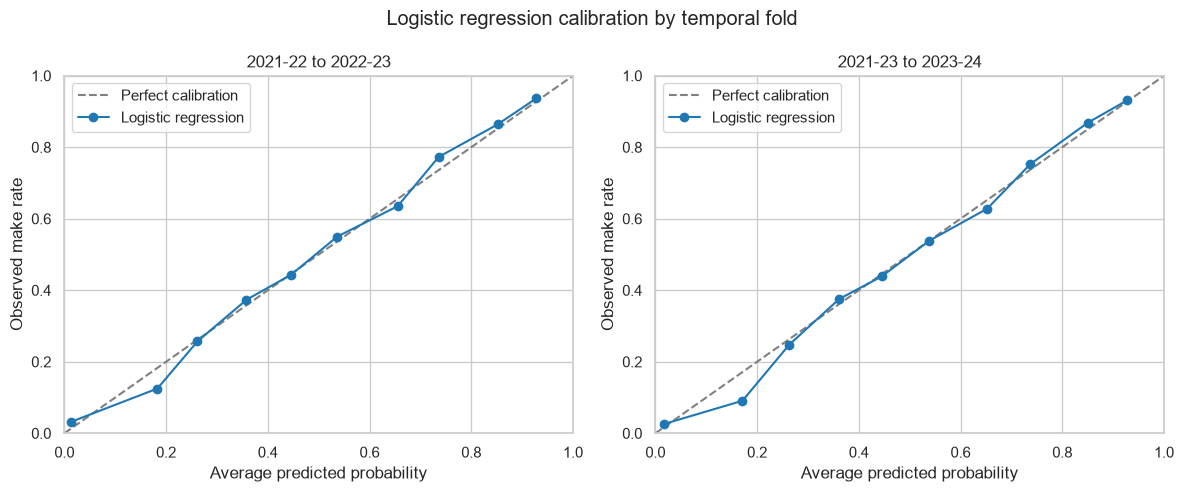

,fold,probability_bin,shots,average_prediction,observed_make_rate
0,2021-22 to 2022-23,"(-0.001, 0.1]",438,0.01313,0.03196
1,2021-22 to 2022-23,"(0.1, 0.2]",56,0.18277,0.12500
2,2021-22 to 2022-23,"(0.2, 0.3]",4335,0.26164,0.25698
3,2021-22 to 2022-23,"(0.3, 0.4]",100445,0.35803,0.37339
4,2021-22 to 2022-23,"(0.4, 0.5]",46556,0.44573,0.44334
5,2021-22 to 2022-23,"(0.5, 0.6]",26169,0.53617,0.54966
6,2021-22 to 2022-23,"(0.6, 0.7]",17476,0.65552,0.63533
7,2021-22 to 2022-23,"(0.7, 0.8]",8687,0.73585,0.77265
8,2021-22 to 2022-23,"(0.8, 0.9]",6144,0.85196,0.86393
9,2021-22 to 2022-23,"(0.9, 1.0]",6912,0.92779,0.93649


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
calibration_tables = []

for axis, fold in zip(axes, folds):
    artifact = fold_artifacts[fold["fold"]]
    table = calibration_table(artifact["target"], artifact["logistic_predictions"])
    nonempty = table.query("shots > 0")
    calibration_tables.append(nonempty.assign(fold=fold["fold"]))

    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    axis.plot(
        nonempty["average_prediction"],
        nonempty["observed_make_rate"],
        marker="o",
        color="#1f77b4",
        label="Logistic regression",
    )
    axis.set_title(fold["fold"])
    axis.set_xlabel("Average predicted probability")
    axis.set_ylabel("Observed make rate")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend()

plt.suptitle("Logistic regression calibration by temporal fold")
plt.tight_layout()
plt.show()

calibration_by_fold = pd.concat(calibration_tables, ignore_index=True)
calibration_by_fold[["fold", "probability_bin", "shots", "average_prediction", "observed_make_rate"]]

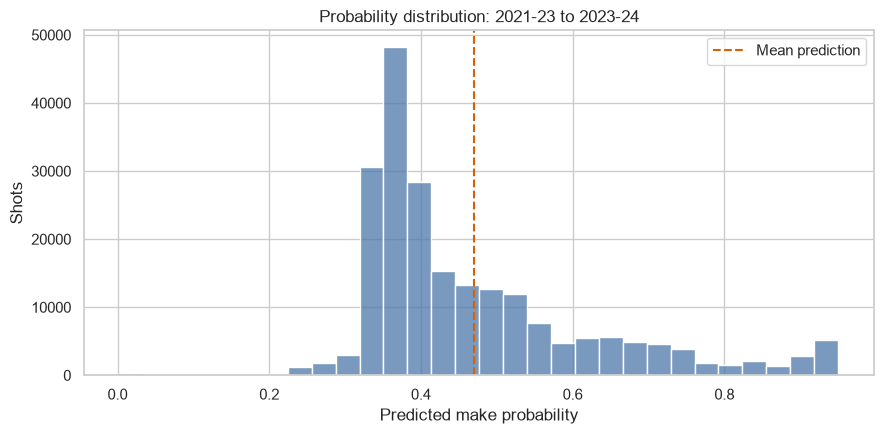

count   218,701.00000
mean          0.47008
std           0.15633
min           0.00359
1%            0.26079
5%            0.33105
50%           0.40571
95%           0.83729
99%           0.93649
max           0.94992
dtype: float64

In [6]:
latest_fold_name = folds[-1]["fold"]
latest_probabilities = fold_artifacts[latest_fold_name]["logistic_predictions"]

plt.figure(figsize=(9, 4.5))
sns.histplot(latest_probabilities, bins=30, color="#4c78a8")
plt.axvline(latest_probabilities.mean(), color="#d95f02", linestyle="--", label="Mean prediction")
plt.xlabel("Predicted make probability")
plt.ylabel("Shots")
plt.title(f"Probability distribution: {latest_fold_name}")
plt.legend()
plt.tight_layout()
plt.show()

pd.Series(latest_probabilities).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

## 5. Coefficient sanity check

The largest coefficients are reviewed only as a modeling sanity check. They are conditional associations, not causal effects, and numeric and one-hot coefficients are not all on the same original scale.

In [7]:
latest_model = fold_artifacts[latest_fold_name]["logistic_model"]
encoded_feature_names = latest_model.named_steps["preprocessing"].get_feature_names_out()
coefficients = latest_model.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame(
    {"encoded_feature": encoded_feature_names, "coefficient": coefficients}
).assign(absolute_coefficient=lambda frame: frame["coefficient"].abs())

coefficient_table.nlargest(15, "absolute_coefficient")[
    ["encoded_feature", "coefficient"]
]

,encoded_feature,coefficient
0,numeric__shot_distance_feet,-1.66618
42,categorical__action_type_Running Dunk Shot,1.58831
13,categorical__action_type_Cutting Dunk Shot,1.38768
40,categorical__action_type_Running Alley Oop Dun...,1.38664
52,categorical__action_type_Tip Layup Shot,-1.30060
62,categorical__shot_zone_basic_Backcourt,-1.23533
36,categorical__action_type_Putback Dunk Shot,1.11863
11,categorical__action_type_Alley Oop Dunk Shot,1.10808
68,categorical__shot_zone_area_Back Court(BC),-1.09782
77,categorical__shot_zone_range_Back Court Shot,-1.09782


## 6. Baseline results

- The logistic baseline improved log loss in both temporal folds: from 0.69234 to 0.63955 for 2022-23 and from 0.69190 to 0.64110 for 2023-24. These are reductions of 7.63% and 7.34%.
- Brier score also improved consistently, dropping by 0.02429 and 0.02334. The context features therefore add meaningful probability resolution beyond the overall make rate.
- Logistic ECE remained low at 0.01310 and 0.01137. The constant model can have a similarly low ECE because one prediction near the overall make rate is calibrated in aggregate, but it cannot distinguish easy and difficult shots. Log loss and Brier score capture that missing resolution.
- The latest-fold logistic probabilities span 0.00359 to 0.94992, with a median of 0.40571. This is a useful spread rather than a narrow cluster around the league average.
- The strongest coefficient directions are basketball-plausible: greater shot distance lowers make probability, dunk categories raise it, and backcourt attempts lower it. Coefficients are used only as a sanity check, not as causal effects.
- Keep this fixed `C=1.0` logistic pipeline as the interpretable baseline. CatBoost must improve log loss in both development folds to justify added complexity.